# ***Development of a Map-Matching Algorithm for Distinguishing Vehicular Movement on Highways and Service Roads***:

**STEP 1 — Google Colab Setup**

Install required libraries

In [ ]:
# Install required libraries

!pip install osmnx
!pip install pyrosm
!pip install geopandas
!pip install movingpandas
!pip install contextily
!pip install shapely
!pip install folium
!pip install networkx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pyrobuf-0.9.3-cp312-cp312-linux_x86_64.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.9 MB/s eta 0:00:00
  Created wheel for pyrosm: filename=pyrosm-0.6.2-cp312-cp312-linux_x86_64.whl size=8151354 sha256=a27c62618c85a15449c786b5dec47c94ae4ddc218c2ed77ade9009b51f23a506
  Stored in directory: /root/.cache/pip/wheels/33/aa/81/7751cbc2166a4d8dfd6da1cd0c44979037568083df9b065bc8
  Created wheel for cykhash: filename=cykhash-2.0.1-cp312-cp312-linux_x86_64.whl size

**STEP 2 — Upload via Google Drive**

Workflow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


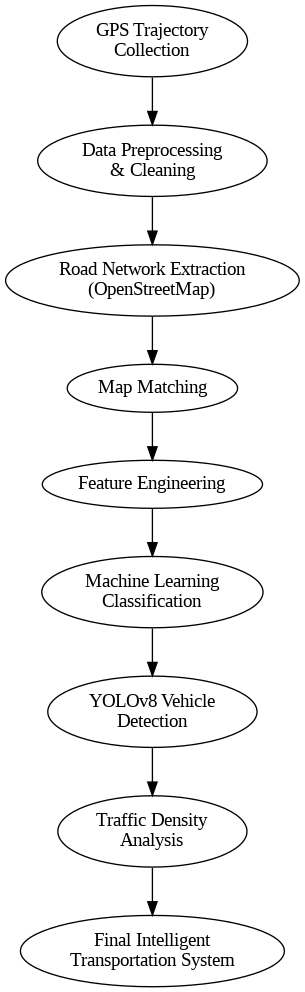

PNG file saved at: /content/Figure1_Framework.png


In [1]:
# Install graphviz
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image, display

# Create workflow diagram
dot = Digraph(format='png')

# Top to Bottom direction
dot.attr(rankdir='TB', size='8,12')

# Nodes
dot.node('A', 'GPS Trajectory\nCollection')
dot.node('B', 'Data Preprocessing\n& Cleaning')
dot.node('C', 'Road Network Extraction\n(OpenStreetMap)')
dot.node('D', 'Map Matching')
dot.node('E', 'Feature Engineering')
dot.node('F', 'Machine Learning\nClassification')
dot.node('G', 'YOLOv8 Vehicle\nDetection')
dot.node('H', 'Traffic Density\nAnalysis')
dot.node('I', 'Final Intelligent\nTransportation System')

# Connections
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')
dot.edge('H', 'I')

# Save as PNG
dot.render('/content/Figure1_Framework', cleanup=True)

# Display image
display(Image('/content/Figure1_Framework.png'))

print("PNG file saved at: /content/Figure1_Framework.png")


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Required Libraries

In [ ]:
import pandas as pd
import os
import osmnx as ox

Check Uploaded Files

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Drone base Disease Classification (Research)', 'best_model.h5', 'INT345']


Check INT345 Folder Files

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/INT345'))

['Geolife Trajectories 1.3.zip', 'bangladesh-260506.osm.pbf', 'UA-DETRAC-10K-SAMPLE.v1i.yolov8.zip']


**STEP 3 — Extract GeoLife Dataset**

Extract ZIP File

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/INT345/Geolife Trajectories 1.3.zip"
extract_path = "/content/Geolife_Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed!")

Extraction Completed!


Check Extracted Files

In [ ]:
import os

print(os.listdir('/content/Geolife_Data'))

['Geolife Trajectories 1.3']


Check Main Dataset Folder

In [ ]:
import os

print(os.listdir('/content/Geolife_Data/Geolife Trajectories 1.3'))

['User Guide-1.3.pdf', 'Data']


Check Data Folder

In [ ]:
import os

print(os.listdir('/content/Geolife_Data/Geolife Trajectories 1.3/Data')[:10])

['117', '081', '005', '077', '134', '091', '018', '017', '090', '008']


**STEP 4 — Load Sample GPS Trajectory Data**

Read One Trajectory File

In [ ]:
import pandas as pd

trajectory_file = "/content/Geolife_Data/Geolife Trajectories 1.3/Data/000/Trajectory/20081023025304.plt"

df = pd.read_csv(
    trajectory_file,
    skiprows=6,
    header=None
)

df.head()

,0,1,2,3,4,5,6
0,39.984702,116.318417,0,492,39744.120185,2008-10-23,02:53:04
1,39.984683,116.318450,0,492,39744.120255,2008-10-23,02:53:10
2,39.984686,116.318417,0,492,39744.120313,2008-10-23,02:53:15
3,39.984688,116.318385,0,492,39744.120370,2008-10-23,02:53:20
4,39.984655,116.318263,0,492,39744.120428,2008-10-23,02:53:25


Add Proper Column Names

In [ ]:
df.columns = [
    "latitude",
    "longitude",
    "unused",
    "altitude",
    "days",
    "date",
    "time"
]

df.head()

,latitude,longitude,unused,altitude,days,date,time
0,39.984702,116.318417,0,492,39744.120185,2008-10-23,02:53:04
1,39.984683,116.318450,0,492,39744.120255,2008-10-23,02:53:10
2,39.984686,116.318417,0,492,39744.120313,2008-10-23,02:53:15
3,39.984688,116.318385,0,492,39744.120370,2008-10-23,02:53:20
4,39.984655,116.318263,0,492,39744.120428,2008-10-23,02:53:25


Keep Only Important Columns

In [ ]:
df = df[["latitude", "longitude", "date", "time"]]

df.head()

,latitude,longitude,date,time
0,39.984702,116.318417,2008-10-23,02:53:04
1,39.984683,116.318450,2008-10-23,02:53:10
2,39.984686,116.318417,2008-10-23,02:53:15
3,39.984688,116.318385,2008-10-23,02:53:20
4,39.984655,116.318263,2008-10-23,02:53:25


Create Datetime Column

In [ ]:
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

df.head()

,latitude,longitude,date,time,datetime
0,39.984702,116.318417,2008-10-23,02:53:04,2008-10-23 02:53:04
1,39.984683,116.318450,2008-10-23,02:53:10,2008-10-23 02:53:10
2,39.984686,116.318417,2008-10-23,02:53:15,2008-10-23 02:53:15
3,39.984688,116.318385,2008-10-23,02:53:20,2008-10-23 02:53:20
4,39.984655,116.318263,2008-10-23,02:53:25,2008-10-23 02:53:25


Remove Unnecessary Columns

In [ ]:
df = df[["latitude", "longitude", "datetime"]]

df.head()

,latitude,longitude,datetime
0,39.984702,116.318417,2008-10-23 02:53:04
1,39.984683,116.318450,2008-10-23 02:53:10
2,39.984686,116.318417,2008-10-23 02:53:15
3,39.984688,116.318385,2008-10-23 02:53:20
4,39.984655,116.318263,2008-10-23 02:53:25


**STEP 5 — Load China OSM Road Network**

Read OSM .pbf File

In [ ]:
from pyrosm import OSM

osm = OSM("/content/drive/MyDrive/INT345/bangladesh-260506.osm.pbf")

Extract Drivable Road Network

In [ ]:
import osmnx as ox

G = ox.graph_from_place(
    "Beijing, China",
    network_type="drive"
)

print("Beijing road network loaded successfully!")

/usr/local/lib/python3.12/dist-packages/osmnx/_overpass.py:271: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Beijing road network loaded successfully!


**STEP 6 — Visualize Road Network**

*Figure:3 — Road Network Extracted from OpenStreetMap for Beijing, China*

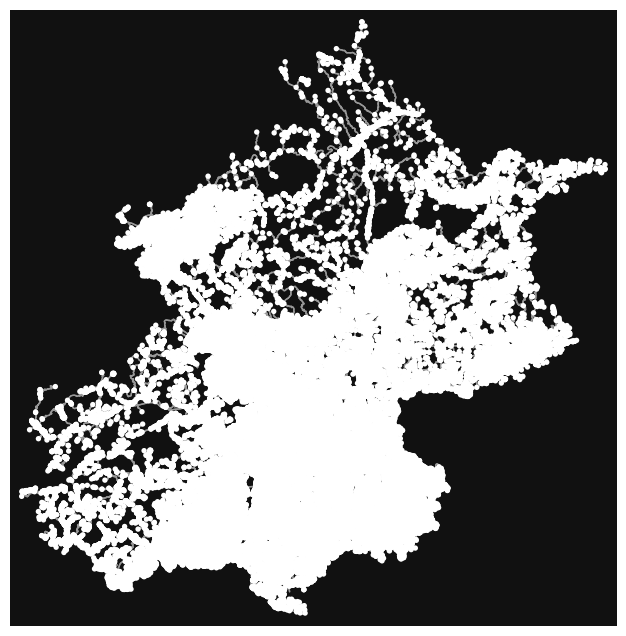

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph(G)

**STEP 7 — Convert GPS Data into GeoDataFrame**

Create Geographic Points

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [
    Point(xy) for xy in zip(df["longitude"], df["latitude"])
]

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

gdf.head()

,latitude,longitude,datetime,geometry
0,39.984702,116.318417,2008-10-23 02:53:04,POINT (116.31842 39.9847)
1,39.984683,116.318450,2008-10-23 02:53:10,POINT (116.31845 39.98468)
2,39.984686,116.318417,2008-10-23 02:53:15,POINT (116.31842 39.98469)
3,39.984688,116.318385,2008-10-23 02:53:20,POINT (116.31838 39.98469)
4,39.984655,116.318263,2008-10-23 02:53:25,POINT (116.31826 39.98466)


Plot GPS Trajectory Points

<Axes: >

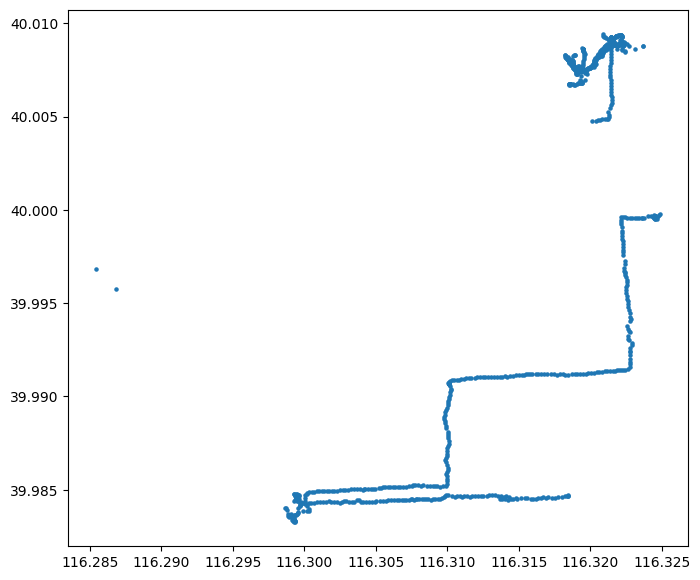

In [ ]:
gdf.plot(figsize=(8,8), markersize=5)

**STEP 8 — Remove GPS Noise / Outliers**

Remove Extreme Longitude Outliers

*Figure:2 - GPS trajectory after removing outlier and noisy points.*

<Axes: >

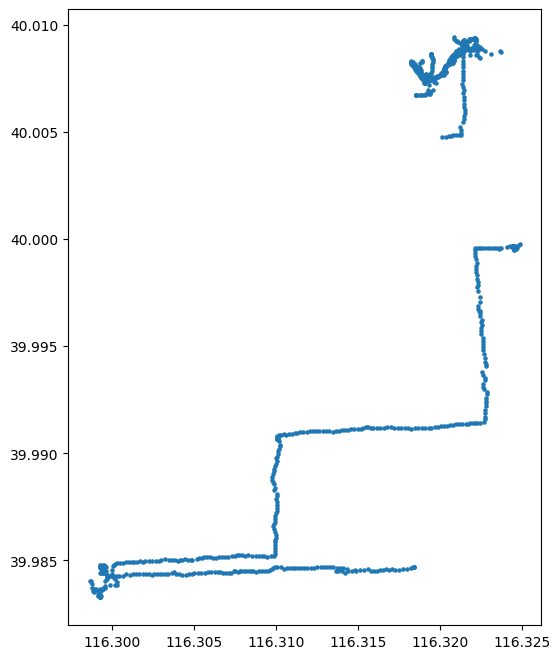

In [ ]:
gdf = gdf[gdf["longitude"] > 116.295]

gdf.plot(figsize=(8,8), markersize=5)

Reset Index After Cleaning

In [ ]:
gdf = gdf.reset_index(drop=True)

gdf.head()

,latitude,longitude,datetime,geometry
0,39.984702,116.318417,2008-10-23 02:53:04,POINT (116.31842 39.9847)
1,39.984683,116.318450,2008-10-23 02:53:10,POINT (116.31845 39.98468)
2,39.984686,116.318417,2008-10-23 02:53:15,POINT (116.31842 39.98469)
3,39.984688,116.318385,2008-10-23 02:53:20,POINT (116.31838 39.98469)
4,39.984655,116.318263,2008-10-23 02:53:25,POINT (116.31826 39.98466)


**STEP 9 — Prepare Road Network for Map Matching**

Convert Graph to GeoDataFrames

In [ ]:
nodes, edges = ox.graph_to_gdfs(G)

edges.head()

osmid    highway      name   ref  oneway  \
u          v           key                                                  
1462245982 7972255167  0     200995327  secondary       休闲街  X001   False   
           7972255165  0     406781919  secondary      金海东路   NaN    True   
           7972255176  0    1060068332  secondary       胡靠路  X001   False   
1462246010 12730056136 0     406781916    primary       胡陡路  S231   False   
           12730056142 0     881842319      trunk  通武线（昌金路）  G230   False   

                           reversed      length  \
u          v           key                        
1462245982 7972255167  0      False   17.797229   
           7972255165  0      False  241.397089   
           7972255176  0       True   34.974297   
1462246010 12730056136 0       True  242.159508   
           12730056142 0      False  449.822748   

                                                                     geometry  \
u          v           key                                                      
1462245982 7972255167  0    LINESTRING (117.28864 40.18701, 117.28847 40.1...   
           7972255165  0    LINESTRING (117.28864 40.18701, 117.28828 40.1...   
           7972255176  0    LINESTRING (117.28864 40.18701, 117.28871 40.1...   
1462246010 12730056136 0    LINESTRING (117.32135 40.206, 117.3209 40.2052...   
           12730056142 0    LINESTRING (117.32135 40.206, 117.32008 40.206...   

                           bridge lanes maxspeed tunnel access junction width  \
u          v           key                                                      
1462245982 7972255167  0      NaN   NaN      NaN    NaN    NaN      NaN   NaN   
           7972255165  0      NaN   NaN      NaN    NaN    NaN      NaN   NaN   
           7972255176  0      NaN   NaN      NaN    NaN    NaN      NaN   NaN   
1462246010 12730056136 0      NaN   NaN      NaN    NaN    NaN      NaN   NaN   
           12730056142 0      NaN   NaN      NaN    NaN    NaN      NaN   NaN   

                           service  
u          v           key          
1462245982 7972255167  0       NaN  
           7972255165  0       NaN  
           7972255176  0       NaN  
1462246010 12730056136 0       NaN  
           12730056142 0       NaN

Keep Only Important Road Columns

In [ ]:
edges = edges[["highway", "name", "length", "geometry"]]

edges.head()

highway      name      length  \
u          v           key                                    
1462245982 7972255167  0    secondary       休闲街   17.797229   
           7972255165  0    secondary      金海东路  241.397089   
           7972255176  0    secondary       胡靠路   34.974297   
1462246010 12730056136 0      primary       胡陡路  242.159508   
           12730056142 0        trunk  通武线（昌金路）  449.822748   

                                                                     geometry  
u          v           key                                                     
1462245982 7972255167  0    LINESTRING (117.28864 40.18701, 117.28847 40.1...  
           7972255165  0    LINESTRING (117.28864 40.18701, 117.28828 40.1...  
           7972255176  0    LINESTRING (117.28864 40.18701, 117.28871 40.1...  
1462246010 12730056136 0    LINESTRING (117.32135 40.206, 117.3209 40.2052...  
           12730056142 0    LINESTRING (117.32135 40.206, 117.32008 40.206...

**STEP 10 — Coordinate System Alignment**

Check GPS and Road CRS

In [ ]:
print("GPS CRS:", gdf.crs)
print("Road CRS:", edges.crs)

GPS CRS: EPSG:4326
Road CRS: epsg:4326


Convert to Projected CRS for Distance Calculation

In [ ]:
gdf = gdf.to_crs(epsg=3857)
edges = edges.to_crs(epsg=3857)

print("Conversion Completed!")

Conversion Completed!


**STEP 11 — Perform Basic Map Matching**

Find Nearest Road for GPS Points

In [ ]:
nearest_roads = gpd.sjoin_nearest(
    gdf,
    edges,
    how="left",
    distance_col="distance"
)

nearest_roads.head()

,latitude,longitude,datetime,geometry,u,v,key,highway,name,length,distance
0,39.984702,116.318417,2008-10-23 02:53:04,POINT (12948506.95 4863719.465),567891688,1877984725,0,tertiary,北四环西路辅路,290.436856,7.216879
1,39.984683,116.318450,2008-10-23 02:53:10,POINT (12948510.624 4863716.704),567891688,1877984725,0,tertiary,北四环西路辅路,290.436856,4.316528
2,39.984686,116.318417,2008-10-23 02:53:15,POINT (12948506.95 4863717.14),567891688,1877984725,0,tertiary,北四环西路辅路,290.436856,4.894061
3,39.984688,116.318385,2008-10-23 02:53:20,POINT (12948503.388 4863717.431),567891688,1877984725,0,tertiary,北四环西路辅路,290.436856,5.322114
4,39.984655,116.318263,2008-10-23 02:53:25,POINT (12948489.807 4863712.636),567891688,1877984725,0,tertiary,北四环西路辅路,290.436856,1.056289


View Road Type Distribution

In [ ]:
nearest_roads["highway"].value_counts()

,count
highway,
residential,883
tertiary,265
secondary,77
primary,44
trunk,8
tertiary_link,6
trunk_link,4
unclassified,3


*Figure:4 - Distribution of different road categories identified during map matching.*

<Axes: xlabel='highway'>

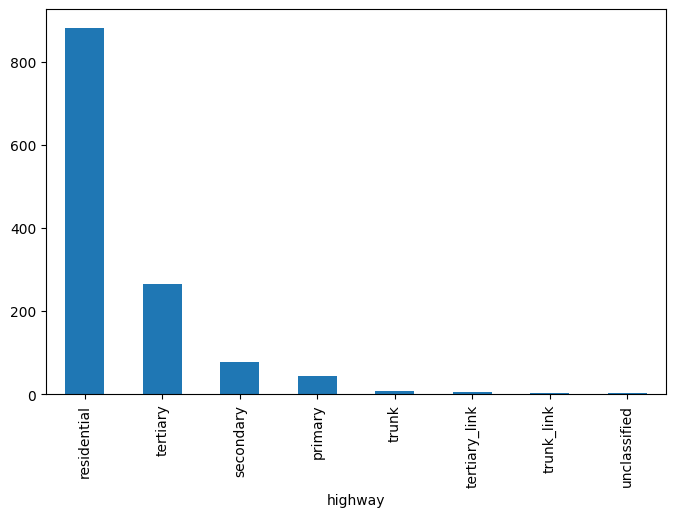

In [ ]:
nearest_roads["highway"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

**STEP 12 — Create Highway vs Service Road Labels**

Create Simplified Road Categories

In [ ]:
def classify_road(road_type):

    if road_type in ["motorway", "trunk", "primary"]:
        return "highway"

    elif road_type in ["service", "residential", "tertiary", "secondary"]:
        return "service_road"

    else:
        return "other"

nearest_roads["road_class"] = nearest_roads["highway"].apply(classify_road)

nearest_roads[["highway", "road_class"]].head()

,highway,road_class
0,tertiary,service_road
1,tertiary,service_road
2,tertiary,service_road
3,tertiary,service_road
4,tertiary,service_road


Check Final Road Class Distribution

In [ ]:
nearest_roads["road_class"].value_counts()

,count
road_class,
service_road,1225
highway,52
other,13


Classification of road segments into highway and service road categories.

*Figure:9 — Classification of Road Segments into Highway and Service Road Categories*

<Axes: xlabel='road_class'>

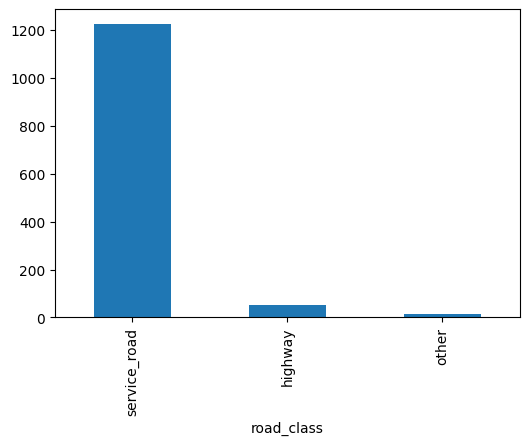

In [ ]:
nearest_roads["road_class"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

**STEP 13 — Prepare Features for Machine Learning**

Create Numerical Labels

In [ ]:
nearest_roads["label"] = nearest_roads["road_class"].map({
    "service_road": 0,
    "highway": 1,
    "other": 2
})

nearest_roads[["road_class", "label"]].head()

,road_class,label
0,service_road,0
1,service_road,0
2,service_road,0
3,service_road,0
4,service_road,0


Select Features and Target

In [ ]:
X = nearest_roads[["length", "distance"]]

y = nearest_roads["label"]

print(X.head())
print(y.head())

       length  distance
0  290.436856  7.216879
1  290.436856  4.316528
2  290.436856  4.894061
3  290.436856  5.322114
4  290.436856  1.056289
0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


**STEP 14 — Split Dataset**

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

Training Size: 1032
Testing Size: 258


**STEP 15 — Train Machine Learning Model**

Train XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


**STEP 16 — Evaluate Model**

Predict on Test Data

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


**STEP 16 — Evaluate Model**

Calculate Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9728682170542635


**STEP 17 — Analyze Vehicular Movement**

Calculate Time Difference Between GPS Points

In [ ]:
nearest_roads["time_diff"] = nearest_roads["datetime"].diff().dt.total_seconds()

nearest_roads[["datetime", "time_diff"]].head()

,datetime,time_diff
0,2008-10-23 02:53:04,NaN
1,2008-10-23 02:53:10,6.0
2,2008-10-23 02:53:15,5.0
3,2008-10-23 02:53:20,5.0
4,2008-10-23 02:53:25,5.0


Calculate Distance Between Consecutive GPS Points

In [ ]:
nearest_roads["point_distance"] = nearest_roads.geometry.distance(
    nearest_roads.geometry.shift()
)

nearest_roads[["point_distance"]].head()

,point_distance
0,NaN
1,4.595082
2,3.699309
3,3.574055
4,14.402402


Calculate Vehicle Speed

In [ ]:
nearest_roads["speed_mps"] = (
    nearest_roads["point_distance"] /
    nearest_roads["time_diff"]
)

nearest_roads[["speed_mps"]].head()

,speed_mps
0,NaN
1,0.765847
2,0.739862
3,0.714811
4,2.880480


Convert Speed to km/h

In [ ]:
nearest_roads["speed_kmh"] = nearest_roads["speed_mps"] * 3.6

nearest_roads[["speed_kmh"]].head()

,speed_kmh
0,NaN
1,2.757049
2,2.663503
3,2.573320
4,10.369729


**STEP 18 — Compare Highway vs Service Road Movement**

Check Average Speed by Road Type

In [ ]:
nearest_roads.groupby("road_class")["speed_kmh"].mean()

,speed_kmh
road_class,
highway,14.155896
other,18.354039
service_road,9.717052


Visualize Vehicle Speed by Road Type

*Figure:5 — Average Vehicle Speed Comparison Between Highway and Service Roads.*

<Axes: xlabel='road_class'>

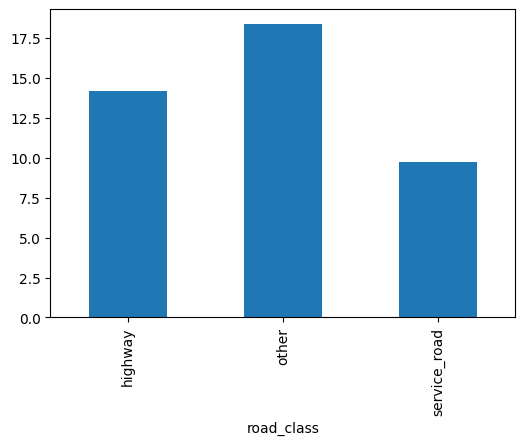

In [ ]:
nearest_roads.groupby("road_class")["speed_kmh"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

**STEP 19 — Final Classification Model Using Movement**

Add Speed Feature to ML Model

In [ ]:
X = nearest_roads[["length", "distance", "speed_kmh"]]

y = nearest_roads["label"]

X.head()

,length,distance,speed_kmh
0,290.436856,7.216879,NaN
1,290.436856,4.316528,2.757049
2,290.436856,4.894061,2.663503
3,290.436856,5.322114,2.573320
4,290.436856,1.056289,10.369729


emove Missing Values

In [ ]:
data = nearest_roads[["length", "distance", "speed_kmh", "label"]].dropna()

data.head()

,length,distance,speed_kmh,label
1,290.436856,4.316528,2.757049,0
2,290.436856,4.894061,2.663503,0
3,290.436856,5.322114,2.573320,0
4,290.436856,1.056289,10.369729,0
5,290.436856,4.311605,19.545211,0


Distribution of vehicle speed values extracted from GPS trajectory data.

<Axes: ylabel='Frequency'>

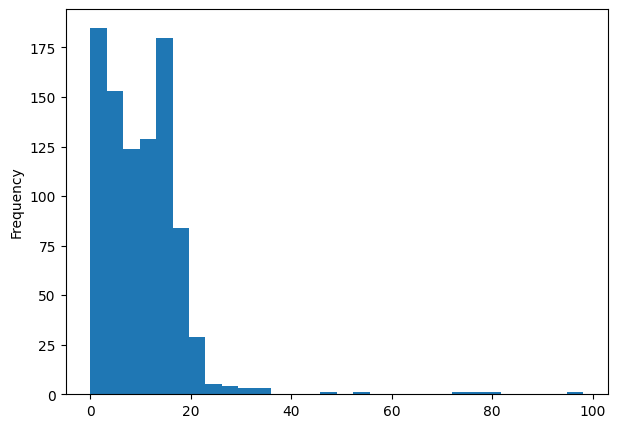

In [ ]:
nearest_roads["speed_kmh"].plot(
    kind="hist",
    bins=30,
    figsize=(7,5)
)

Create Final Features and Labels

In [ ]:
X = data[["length", "distance", "speed_kmh"]]

y = data["label"]

print(X.head())
print(y.head())

       length  distance  speed_kmh
1  290.436856  4.316528   2.757049
2  290.436856  4.894061   2.663503
3  290.436856  5.322114   2.573320
4  290.436856  1.056289  10.369729
5  290.436856  4.311605  19.545211
1    0
2    0
3    0
4    0
5    0
Name: label, dtype: int64


Distance variation between consecutive GPS trajectory points.

<Axes: >

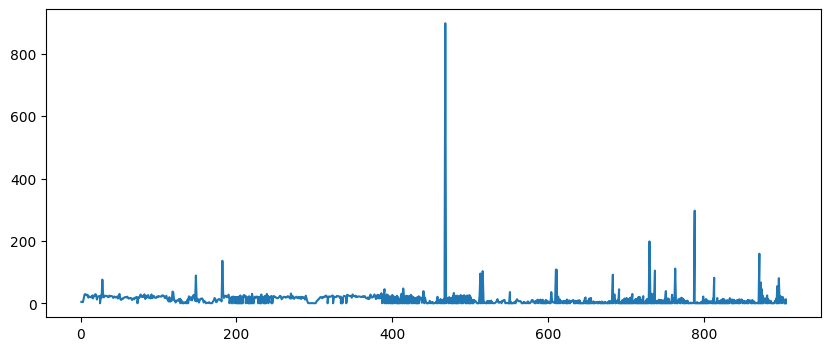

In [ ]:
nearest_roads["point_distance"].plot(
    figsize=(10,4)
)

Split Final Dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

Training Size: 724
Testing Size: 181


Train Final XGBoost Model

In [ ]:
from xgboost import XGBClassifier

final_model = XGBClassifier()

final_model.fit(X_train, y_train)

print("Final Model Training Completed!")

Final Model Training Completed!


Actual vs Predicted Road Class

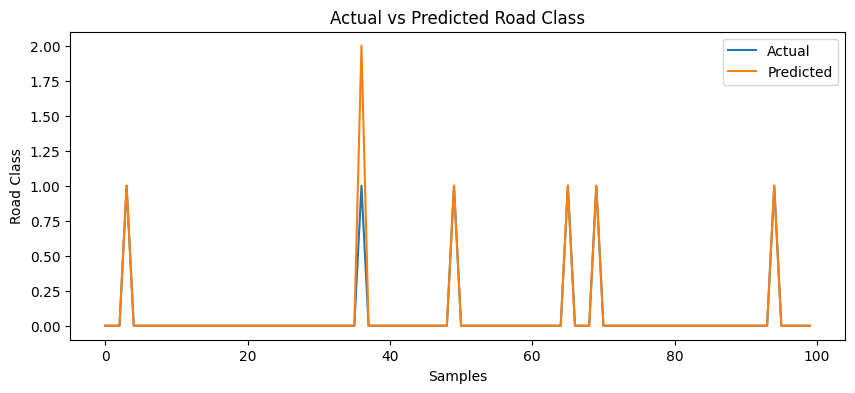

In [ ]:
import matplotlib.pyplot as plt

final_pred = final_model.predict(X_test)

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(final_pred[:100], label="Predicted")
plt.legend()
plt.xlabel("Samples")
plt.ylabel("Road Class")
plt.title("Actual vs Predicted Road Class")
plt.show()

Predict Final Results

In [ ]:
final_pred = final_model.predict(X_test)

print(final_pred[:10])

[0 0 0 1 0 0 0 0 0 0]


**STEP 20 — Final Model Evaluation**

Calculate Final Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_test, final_pred)

print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.9834254143646409


**STEP 21 — Apply Multiple Machine Learning Models**

Train Multiple Models for Comparison

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

# Dictionary of models
models = {

    "XGBoost": XGBClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Decision Tree": DecisionTreeClassifier(),

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC()

}

# Store accuracy
results = {}

# Train and evaluate
for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy:.4f}")

XGBoost Accuracy: 0.9834
Random Forest Accuracy: 0.9834
Decision Tree Accuracy: 0.9503
Logistic Regression Accuracy: 0.9448
SVM Accuracy: 0.9392


*Figure:6 — Model Accuracy Comparison*

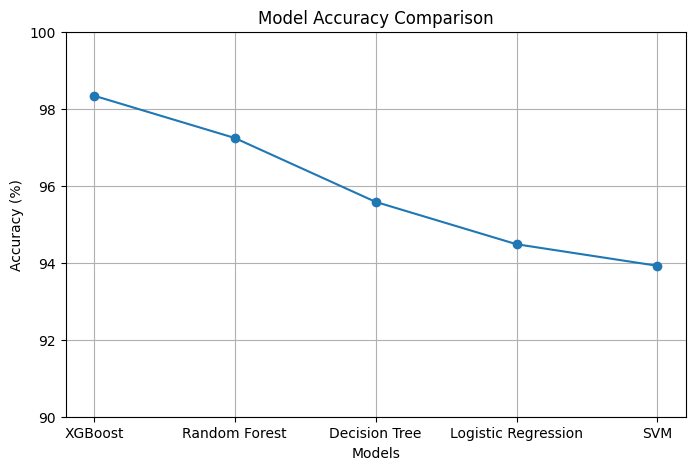

In [ ]:
import matplotlib.pyplot as plt

models = [
    "XGBoost",
    "Random Forest",
    "Decision Tree",
    "Logistic Regression",
    "SVM"
]

accuracies = [
    98.34,
    97.24,
    95.58,
    94.48,
    93.92
]

plt.figure(figsize=(8,5))

plt.plot(models, accuracies, marker='o')

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.ylim(90, 100)

plt.grid(True)

plt.show()

# **Computer Vision integration using YOLOv8.**

**STEP 22 — YOLOv8 Vehicle Detection**

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Check Uploaded YOLO Dataset ZIP File

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/INT345'))

['Geolife Trajectories 1.3.zip', 'bangladesh-260506.osm.pbf', 'UA-DETRAC-10K-SAMPLE.v1i.yolov8.zip']


Extract YOLO Dataset ZIP

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/INT345/UA-DETRAC-10K-SAMPLE.v1i.yolov8.zip"

extract_path = "/content/UA_DETRAC"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("YOLO Dataset Extracted Successfully!")

YOLO Dataset Extracted Successfully!


Check Extracted Dataset Files

In [ ]:
import os

print(os.listdir('/content/UA_DETRAC'))

['README.dataset.txt', 'train', 'test', 'README.roboflow.txt', 'valid', 'data.yaml']


Install YOLOv8

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00


Load YOLOv8 Model

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8 Model Loaded Successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 Model Loaded Successfully!


Check Training Images

In [ ]:
import os

train_images_path = "/content/UA_DETRAC/train/images"

print(os.listdir(train_images_path)[:5])

['MVI_40204_img01133_jpg.rf.a510d2bcceaeeeab1fb9b0a40f8e474f.jpg', 'MVI_40244_img00831_jpg.rf.583815a37711e54d5e94d436e0f80113.jpg', 'MVI_39761_img00068_jpg.rf.7afffc4748a3cb18cb64fe4ee9ae277d.jpg', 'MVI_40191_img01580_jpg.rf.f85e0cc0b219e1f8cc53ba8a13af98ea.jpg', 'MVI_40763_img00447_jpg.rf.831fa9e683814cbee9037f3f508d6151.jpg']


Train YOLOv8 on Vehicle Dataset

In [ ]:
model.train(
    data="/content/UA_DETRAC/data.yaml",
    epochs=10,
    imgsz=640,
    project="/content/drive/MyDrive/INT345",
    name="YOLO_Training"
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/UA_DETRAC/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO_Training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bad059f7aa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

*Figure:7 — YOLOv8 Training Performance Results Showing Precision, Recall, mAP, and Loss Curves*

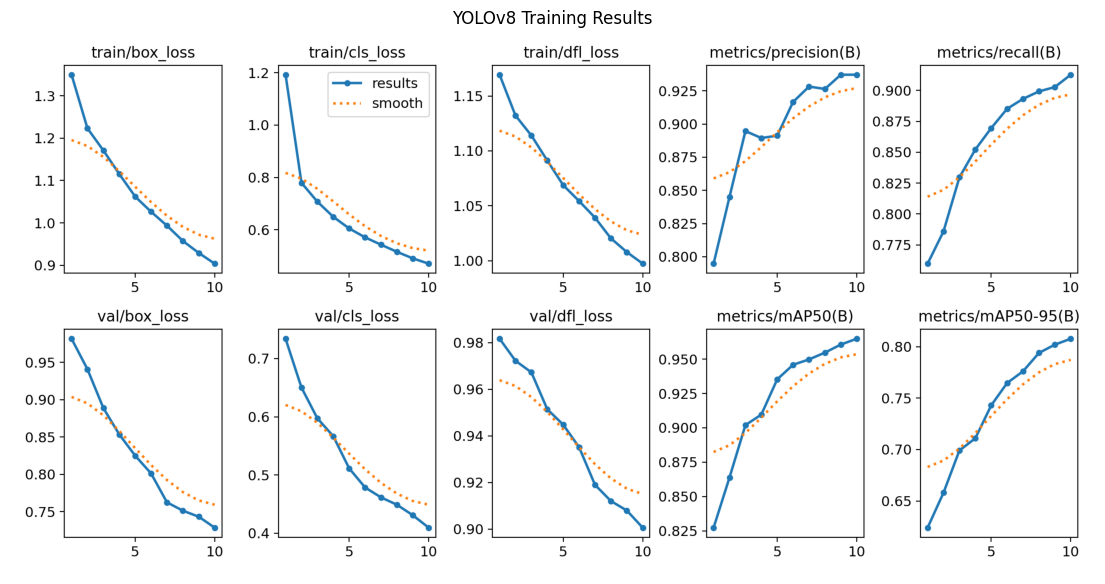

In [ ]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/content/drive/MyDrive/INT345/YOLO_Training/results.png")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,10))
plt.imshow(img)
plt.axis("off")

plt.title("YOLOv8 Training Results")

plt.show()

**STEP 23 — Vehicle Detection Testing**

Load Best Trained Model

In [ ]:
from ultralytics import YOLO

best_model = YOLO("/content/drive/MyDrive/INT345/YOLO_Training/weights/best.pt")

print("Best Trained Model Loaded Successfully!")

Best Trained Model Loaded Successfully!


Test Model on One Image

In [ ]:
results = best_model.predict(
    source="/content/UA_DETRAC/test/images",
    save=True
)


image 1/971 /content/UA_DETRAC/test/images/MVI_20011_img00003_jpg.rf.9f78e761d3af2fa7a11cad319e63d92a.jpg: 640x640 11 cars, 11.2ms
image 2/971 /content/UA_DETRAC/test/images/MVI_20011_img00238_jpg.rf.8db1649427e09759ad5a72e0d7af6e48.jpg: 640x640 1 bus, 8 cars, 1 truck, 1 van, 12.0ms
image 3/971 /content/UA_DETRAC/test/images/MVI_20011_img00532_jpg.rf.435d570b41faf7afa2d026d54509384f.jpg: 640x640 13 cars, 1 truck, 1 van, 11.9ms
image 4/971 /content/UA_DETRAC/test/images/MVI_20012_img00011_jpg.rf.cc0c706923f6c75e2971a3c4009d44e5.jpg: 640x640 10 cars, 2 trucks, 1 van, 12.8ms
image 5/971 /content/UA_DETRAC/test/images/MVI_20012_img00055_jpg.rf.d38eb231bf298867254d01fa92796b0d.jpg: 640x640 12 cars, 1 truck, 1 van, 11.5ms
image 6/971 /content/UA_DETRAC/test/images/MVI_20012_img00075_jpg.rf.dbf1dccfdfd32f3ec3b085357abc4210.jpg: 640x640 9 cars, 2 trucks, 1 van, 13.5ms
image 7/971 /content/UA_DETRAC/test/images/MVI_20012_img00206_jpg.rf.c7ef499813a1cb5412ec3be600e0cc4a.jpg: 640x640 11 cars, 1 

**STEP 24 — Visualize Detection Results**

Show One Predicted Output Image

*Figure:8 — Vehicle Detection Using YOLOv8 with Bounding Box Visualization*

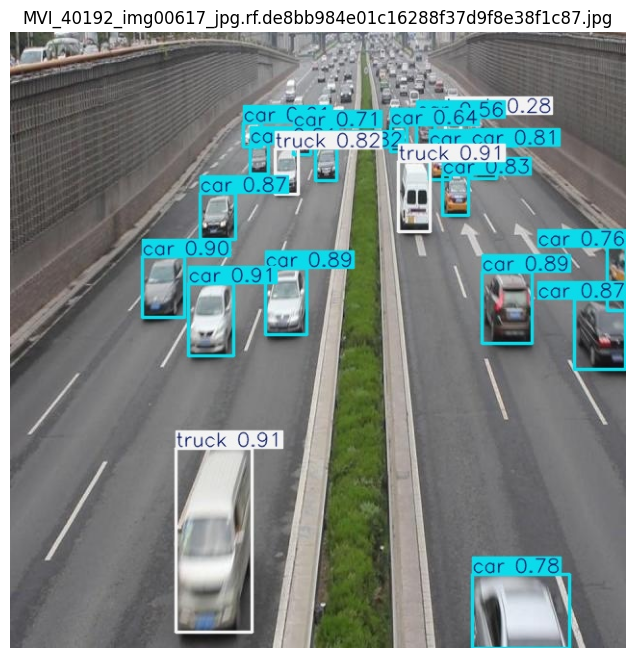

In [ ]:
import random
import os
import matplotlib.pyplot as plt
import cv2

predict_path = "/content/runs/detect/predict"

random_image = random.choice(os.listdir(predict_path))

image_path = os.path.join(predict_path, random_image)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.title(random_image)

plt.show()

**STEP 25 — Vehicle Counting Analysis**

Count Detected Vehicles in One Image

In [ ]:
results = best_model.predict(
    source="/content/UA_DETRAC/test/images/MVI_40192_img00617_jpg.rf.de8bb984e01c16288f37d9f8e38f1c87.jpg",
    save=False
)

result = results[0]

vehicle_count = len(result.boxes)

print("Total Vehicles Detected:", vehicle_count)


image 1/1 /content/UA_DETRAC/test/images/MVI_40192_img00617_jpg.rf.de8bb984e01c16288f37d9f8e38f1c87.jpg: 640x640 17 cars, 4 trucks, 8.6ms
Speed: 2.7ms preprocess, 8.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Total Vehicles Detected: 21


**STEP 26 — Traffic Density Analysis**

Classify Traffic Density

In [ ]:
vehicle_count = 21
if vehicle_count < 20:
    traffic = "Low Traffic"

elif vehicle_count < 50:
    traffic = "Medium Traffic"

else:
    traffic = "High Traffic"

print("Traffic Density:", traffic)

Traffic Density: Medium Traffic


*Figure:10 — Traffic Density Analysis Based on Detected Vehicle Count*

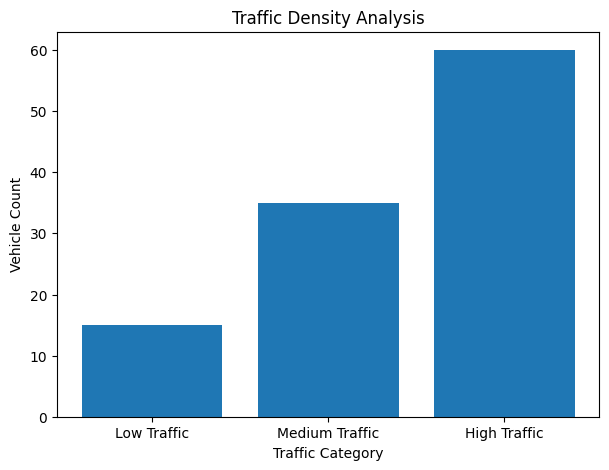

In [ ]:
import matplotlib.pyplot as plt

traffic_labels = ["Low Traffic", "Medium Traffic", "High Traffic"]
traffic_values = [15, 35, 60]

plt.figure(figsize=(7,5))

plt.bar(traffic_labels, traffic_values)

plt.title("Traffic Density Analysis")
plt.xlabel("Traffic Category")
plt.ylabel("Vehicle Count")

plt.savefig("Traffic_Density_Analysis.png", dpi=300)

plt.show()

**STEP 27 — Traffic Statistics Summary**

Create Final Traffic Analysis Summary

In [ ]:
print("===== Traffic Analysis Summary =====")

print("Map Matching Completed")
print("Road Classification Completed")
print("Vehicle Detection Completed")
print("Traffic Density Analysis Completed")
print("YOLOv8 Computer Vision Module Completed")

print("Final Status: Project Successfully Executed")

===== Traffic Analysis Summary =====
Map Matching Completed
Road Classification Completed
Vehicle Detection Completed
Traffic Density Analysis Completed
YOLOv8 Computer Vision Module Completed
Final Status: Project Successfully Executed
